# AE 02: Diwali sales + EDA
### Author: Ripa Shah
### Date: 09/11/2025

## Exercise 1

### Reading and Examining the Data


1.  **Read in the data:**

    -   Read the Diwali sales data into a Pandas DataFrame and display the first few rows.

In [5]:
%cd C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah

C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah


In [6]:

import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import skewnorm
from scipy.stats import kurtosis, norm
from scipy.stats import gamma
import missingno as msno
#import random
#import statsmodels.api as sm


current_directory = os.getcwd()
print(current_directory)
file_path = os.path.join(current_directory, 'data', 'diwali_sales_data.csv')
df=pd.read_csv(file_path, encoding = 'iso-8859-1')
print(df)




C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah
       User_ID    Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
0      1002903    Sanskriti  P00125942      F     26-35   28               0   
1      1000732       Kartik  P00110942      F     26-35   35               1   
2      1001990        Bindu  P00118542      F     26-35   35               1   
3      1001425       Sudevi  P00237842      M      0-17   16               0   
4      1000588         Joni  P00057942      M     26-35   28               1   
...        ...          ...        ...    ...       ...  ...             ...   
11246  1000695      Manning  P00296942      M     18-25   19               1   
11247  1004089  Reichenbach  P00171342      M     26-35   33               0   
11248  1001209        Oshin  P00201342      F     36-45   40               0   
11249  1004023       Noonan  P00059442      M     36-45   37               0   
11250  1002744      Brumley  P00281742      F     

2.  **Examine the Data:**
    -   Display basic information about the dataset using the `.info()` method.

    -   Display summary statistics for the numerical columns using the `.describe()` method.

In [7]:
# add code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [8]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


*Add narrative here*

::: callout-important
Now is a good time to render, commit, and push.
Make sure that you commit and push all changed documents and your Git pane is completely empty before proceeding.
:::

## Exercise 2

### Exploring unique levels, outliers, and missing values


1.  **Exploring Unique Levels:**

    -   Identify and display the unique values in each categorical column.

In [9]:
# add code here
categorical_col= df.select_dtypes(include=['object','category']).columns
print(categorical_col)

import pandas as pd

unique_df = pd.DataFrame({
    'Column': categorical_col,
    'Unique Levels': [df[col].unique() for col in categorical_col]
})
print(unique_df)

Index(['Cust_name', 'Product_ID', 'Gender', 'Age Group', 'State', 'Zone',
       'Occupation', 'Product_Category'],
      dtype='object')
             Column                                      Unique Levels
0         Cust_name  [Sanskriti, Kartik, Bindu, Sudevi, Joni, Balk,...
1        Product_ID  [P00125942, P00110942, P00118542, P00237842, P...
2            Gender                                             [F, M]
3         Age Group     [26-35, 0-17, 18-25, 55+, 46-50, 51-55, 36-45]
4             State  [Maharashtra, Andhra Pradesh, Uttar Pradesh, K...
5              Zone    [Western, Southern, Central, Northern, Eastern]
6        Occupation  [Healthcare, Govt, Automobile, Construction, F...
7  Product_Category  [Auto, Hand & Power Tools, Stationery, Tupperw...


2.  **Identifying and Visualizing Outliers:**

    -   Create a box plot to visualize outliers in the `Amount` column.

    -   Identify outliers using the IQR method and count the number of outliers for each numerical column.

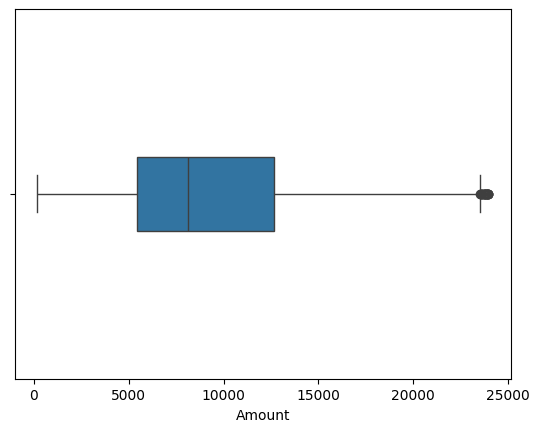

In [10]:
# add code here
import seaborn as sns

sns.boxplot(data = df, x ='Amount', width = 0.20)
plt.show()

In [11]:
for column in df.select_dtypes(include=np.number).columns:
    q25 = df[column].quantile(0.25)
    q75 = df[column].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers = df[df[column] < lower_bound] | df[df[column] > upper_bound]
    print(f"{column} : {outliers.shape[0]} outliers")


User_ID : 0 outliers
Age : 283 outliers
Marital_Status : 0 outliers
Orders : 0 outliers
Amount : 19 outliers


2.  **Handling Missing Values:**

    -   Check for missing values in the dataset.

In [13]:
# add code here
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [ ]:
By above data, we can see that Amount column has 19 outliers. Also, I'm seeing 12 missing values in amount column

*Add narrative here.*

::: callout-important
Now is a good time to render, commit, and push.
Make sure that you commit and push all changed documents and your Git pane is completely empty before proceeding.
:::